# O Método de Monte Carlo – Modelo de Ising 2D usando Algoritmo de Metropolis

Vinicius Trindade Dias Abel

## Parte 1 - Processo de Termalização

O Processo de Termalização é a fase inicial de uma simulação de Monte Carlo onde o sistema evolui para atingir o equilíbrio termodinâmico. Durante esse processo, as configurações iniciais são descartadas até que o sistema comece a oscilar ao redor de um valor médio estável, indicando que atingiu o estado estacionário.

### Modelo de Ising

O modelo de Ising é usado na termalização para estudar como sistemas físicos atingem o equilíbrio termodinâmico. Ele simula uma rede de spins, facilitando a análise da energia e magnetização enquanto o sistema se ajusta ao equilíbrio.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

In [ ]:
def vizinhos(S):
  N = len(S)
  L= np.sqrt(N)
  viz = np.zeros((N,4), dtype=np.int16)

  for k in range(N):
    viz[k, 0] =  k + 1
    if (k + 1) % L == 0 : viz[k, 0] = k + 1 - L

    viz[k, 1] = k + L
    if k > (N - L - 1) : viz[k, 1] = k + L - N

    viz[k, 2] = k - 1
    if k % L == 0 : viz[k, 2] = k + L - 1

    viz[k, 3] = k - L
    if k < L : viz[k, 3] = k + N - L

  return viz

@jit(nopython = True)
def energia(S, viz):
  #Calcula a energia da configuração representada no array s
  N = len(S)
  ener = 0
  for i in range(N):
    h = (S[viz[i, 0]] + S[viz[i, 1]]) # soma do valor dos spins a direita e acima
    ener -= S[i] * h
  return ener

### Algoritmo de Metropolis

O algoritmo de Metropolis é utilizado no modelo de Ising para simular a evolução do sistema até o equilíbrio. Ele gera novas configurações de estados de acordo com a energia: configurações que diminuem a energia são aceitas automaticamente, enquanto aquelas que aumentam a energia são aceitas com uma certa probabilidade. Esse método permite que o sistema alcance gradualmente um estado de equilíbrio.

In [ ]:
@jit(nopython=True)
def expos(beta):
  ex = { -8: np.exp(8.0 * beta), -4: np.exp(4.0 * beta), 0: 1.0, 4: np.exp(-4.0 * beta), 8: np.exp(-8.0 * beta) }
  return ex

# Algoritmo de Metropolis
@jit(nopython = True)
def metropolis(S, viz, ener, mag, ex):
    N = len(S)
    for i in range(N):
        k = np.random.randint(N)

        h = S[viz[k, 0]] + S[viz[k, 1]] + S[viz[k, 2]] + S[viz[k, 3]]
        de = S[k] * h * 2

        if np.random.rand() < ex[de]:
            S[k] = -S[k]
            ener += de
            mag += 2 * S[k]

    return S, ener, mag

### Funções para criar e plotar as simulações

In [ ]:
def termalizacao(L, beta, passos_mc):
    N = L * L
    S = np.random.choice([-1, 1], size=N).astype(np.int8)
    viz = vizinhos(S)
    ener = energia(S, viz)
    mag = np.sum(S)
    ex = expos(beta)

    energias = []
    magnetizacoes = []

    for passo in range(passos_mc):
        S, ener, mag = metropolis(S, viz, ener, mag, ex)
        energias.append(ener)
        magnetizacoes.append(mag)

    return energias, magnetizacoes

In [ ]:
def simulacoes(L, beta, n, passos_mc, last_mc):
    energias = []
    magnetizacoes = []
    last_energias = []
    last_magnetizacoes = []

    for i in range(n):
        ener, mag = termalizacao(L, beta, passos_mc)
        energias.append(ener)
        magnetizacoes.append(mag)

        last_energias.append(-np.array(ener)[-last_mc:])
        last_magnetizacoes.append(np.abs(np.array(mag)[-last_mc:]))

    return (np.array(energias), np.array(magnetizacoes), np.array(last_energias), np.array(last_magnetizacoes))

In [ ]:
def plotagem(titulo_1, titulo_2, energias, magnetizacoes, n):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

    for i in range(n):
        ax1.plot(energias[i], linewidth=0.8, alpha=0.92)
    ax1.set_xlabel('Passos de Monte Carlo')
    ax1.set_ylabel('Energia')
    ax1.set_title(titulo_1)
    for i in range(n):
        ax2.plot(magnetizacoes[i], linewidth=0.8, alpha=0.92)
    ax2.set_xlabel('Passos de Monte Carlo')
    ax2.set_ylabel('Magnetização')
    ax2.set_title(titulo_2)

    plt.tight_layout()
    plt.show()

### Simulações

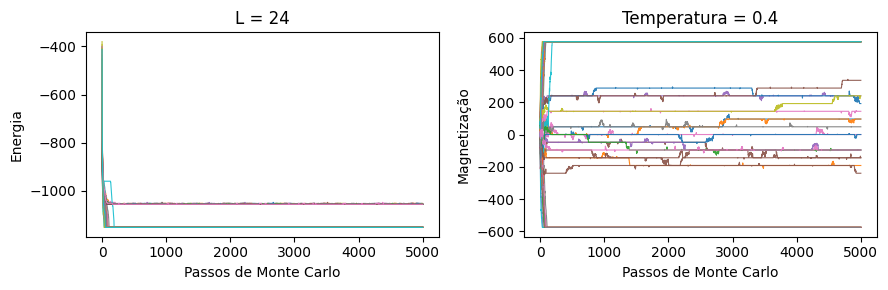

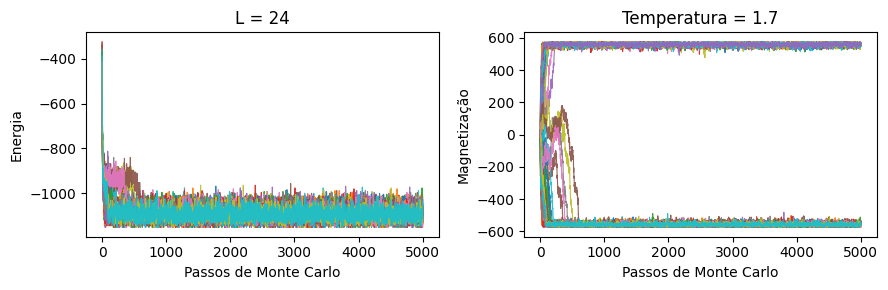

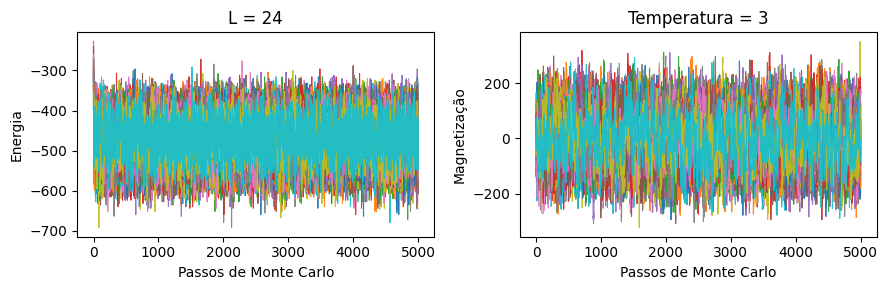

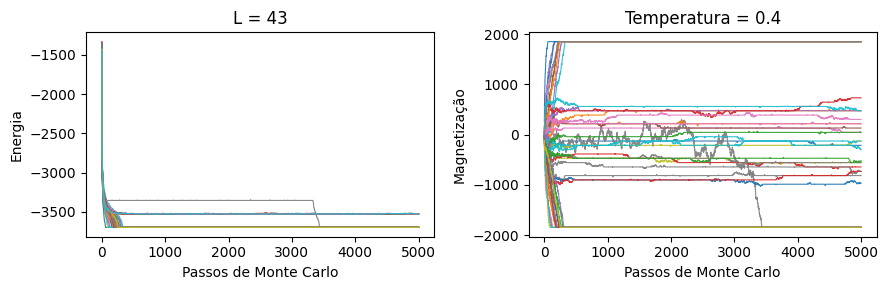

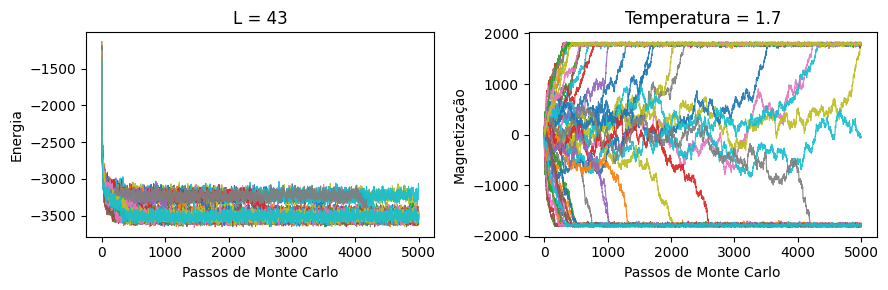

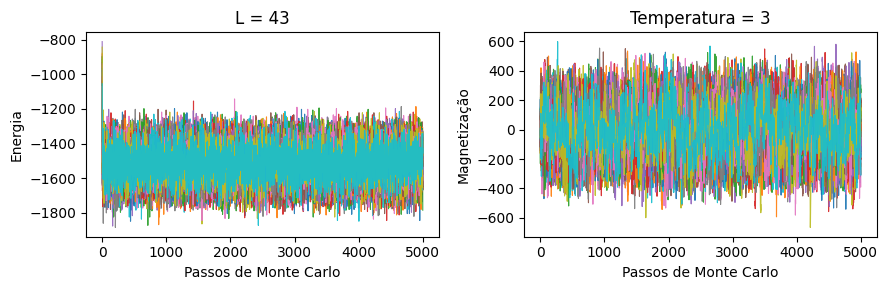

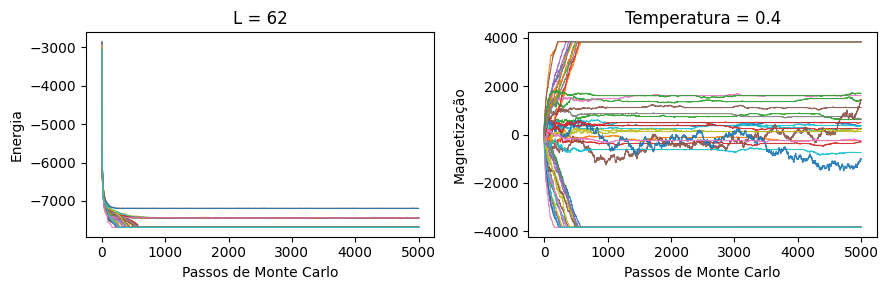

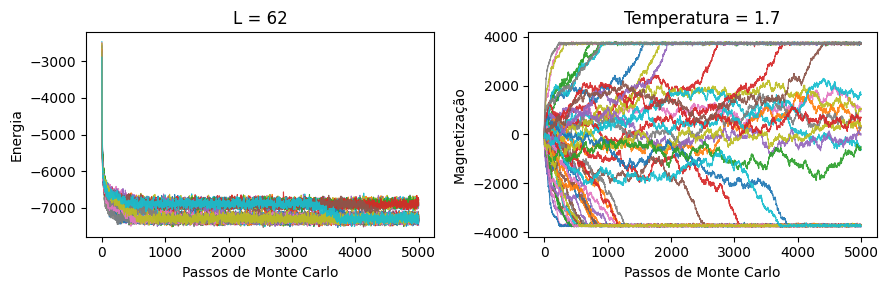

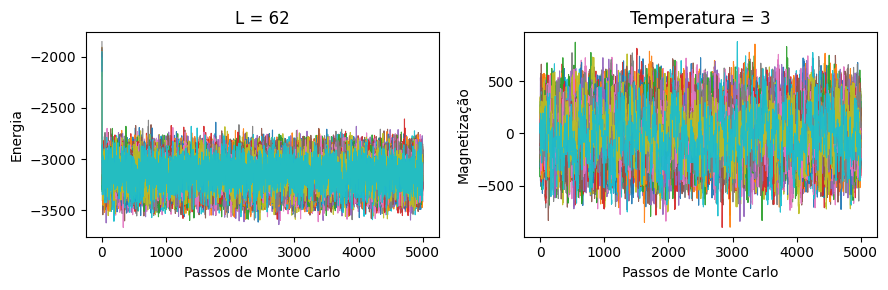

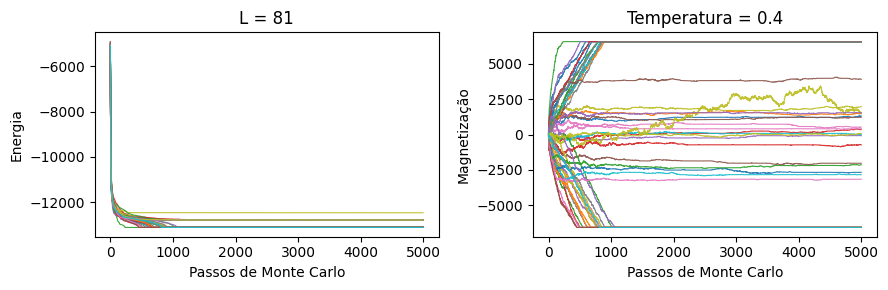

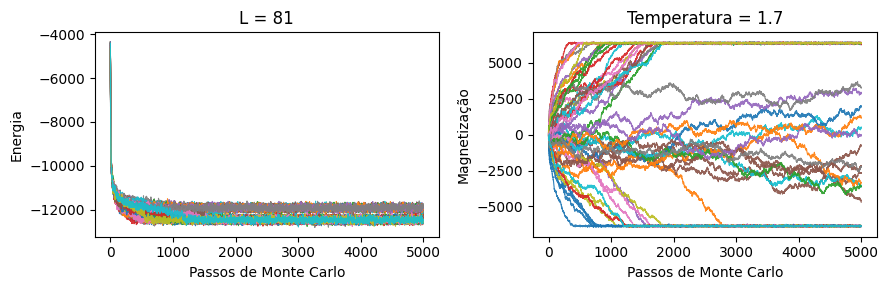

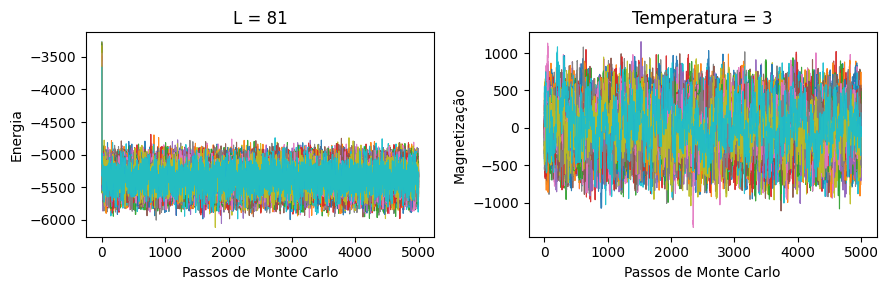

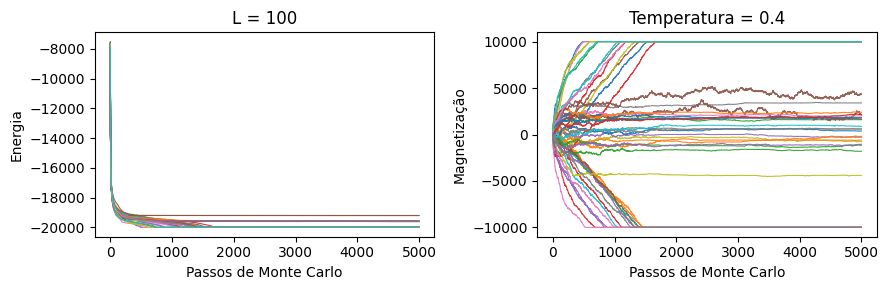

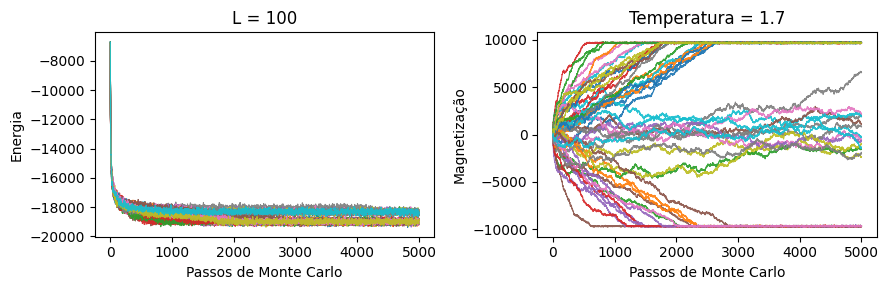

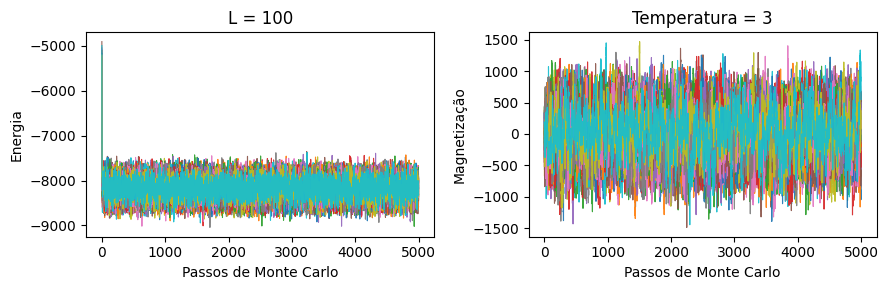

In [ ]:
# Parâmetros globais
passos_mc = 5000
last_mc = 1000
n = 50

# Simulacoes L = 24
L = 24
T = 0.4
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 24", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 24", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 24", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 43
L = 43
T = 0.4
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 43", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 43", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 43", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 62
L = 62
T = 0.4
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 62", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 62", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 62", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 81
L = 81
T = 0.4
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 81", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 81", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 81", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 100
L = 100
T = 0.4
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 100", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 100", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)
plotagem("L = 100", "Temperatura = 3", energias, magnetizacoes, n)

### Critérios de escolha de parâmetros

Os valores de 𝐿 e 𝑇 foram escolhidos a partir do intervalo sugerido no enunciado, com 𝐿 no intervalo [24, 100] e 𝑇 em [0.4, 3]. Dividi cada parâmetro em intervalos igualmente espaçados, resultando nos valores 𝐿 = (24, 43, 62, 81, 100) e 𝑇 =(0.4, 1.7, 3). Essa divisão permitiu uma análise gradual do impacto de variações de 𝐿 e 𝑇 no comportamento do sistema. O número de passos de Monte Carlo foi definido em 5000, proporcionando um tempo de simulação de aproximadamente 20 minutos, o suficiente para obter dados interessantes para análise.

### Análise de Resultados

**Energia**

* Variação de Temperatura

  Com o aumento da temperatura, a energia do sistema leva mais tempo para convergir e tende a atingir valores mais altos, indicando maior desordem.

* Variação de L

  À medida que o tamanho da rede (L) aumenta, a energia de convergência diminui, o que leva a um valor total maior de interações. No entanto, o aumento de L não parece alterar o número de passos de Monte Carlo necessários para a estabilização.


**Magnetização**

* Variação de Temperatura

  Em baixas temperaturas, poucas instâncias convergem. Temperaturas medianas geram mais convergência, mas, em temperaturas elevadas, a magnetização se torna caótica, dificultando a estabilização.

* Variação de L

  Com o aumento de L, o valor de magnetização de convergência cresce, e o sistema leva mais tempo para estabilizar, devido ao maior número de spins que precisam se alinhar.

| Tamanho da Rede \(L\) | Temperatura \(T\) | Passos de Termalização (estimado) |
|-----------------------|-------------------|------------------------------------|
| 24                    | 0.4               | 500                                |
| 24                    | 1.7               | 700                                |
| 24                    | 3.0               | -                               |
| 43                    | 0.4               | 500                                |
| 43                    | 1.7               | 3000                                |
| 43                    | 3.0               | -                               |
| 62                    | 0.4               | 700                                |
| 62                    | 1.7               | -                                |
| 62                    | 3.0               | -                               |
| 81                    | 0.4               | 1100                                |
| 81                    | 1.7               | -                               |
| 81                    | 3.0               | -                               |
| 100                   | 0.4               | -                                |
| 100                   | 1.7               | -                               |
| 100                   | 3.0               | -                               |

Valores superiores a 3000 não são visiveis nos gráficos e, por isso, não foram estimados

## Parte 2 - Propriedades Termodinâmicas

### Método de caixas

O método de caixas é utilizado para estimar os erros estatísticos presente nas simulações.

In [1]:
def metodo_caixas(energias, magnetizacoes, beta, L, n):
    N = L * L
    medias_termo = len(energias)
    m = medias_termo // n

    cv_caixas = []
    chi_caixas = []
    energia_caixas = []
    magnetizacao_caixas = []

    for i in range(n):
        inicio_idx = i * m
        fim_idx = inicio_idx + m

        energias_caixa = energias[inicio_idx:fim_idx]
        magnetizacoes_caixa = magnetizacoes[inicio_idx:fim_idx]

        if len(energias_caixa) == 0 or len(magnetizacoes_caixa) == 0:
            continue

        energias_2_caixa = energias_caixa**2
        magnetizacoes_2_caixa = magnetizacoes_caixa**2
        media_E_i = np.mean(energias_caixa)
        media_E2_i = np.mean(energias_2_caixa)
        media_M_i = np.mean(magnetizacoes_caixa)
        media_M2_i = np.mean(magnetizacoes_2_caixa)
        cv_i = (beta**2 / N) * (media_E2_i - media_E_i**2)
        cv_caixas.append(cv_i)
        chi_i = (beta / N) * (media_M2_i - media_M_i**2)
        chi_caixas.append(chi_i)
        energia_caixas.append(media_E_i)
        magnetizacao_caixas.append(media_M_i)

    cv_medio = np.mean(cv_caixas)
    chi_medio = np.mean(chi_caixas)
    energia_media = np.mean(energia_caixas)
    magnetizacao_media = np.mean(magnetizacao_caixas)

    erro_cv = np.sqrt(np.sum((cv_caixas - cv_medio)**2) / (n * (n - 1)))
    erro_chi = np.sqrt(np.sum((chi_caixas - chi_medio)**2) / (n * (n - 1)))
    erro_energia = np.sqrt(np.sum((energia_caixas - energia_media)**2) / (n * (n - 1)))
    erro_magnetizacao = np.sqrt(np.sum((magnetizacao_caixas - magnetizacao_media)**2) / (n * (n - 1)))

    return {"cv_medio": cv_medio,
        "erro_cv": erro_cv,
        "chi_medio": chi_medio,
        "erro_chi": erro_chi,
        "energia_media": energia_media,
        "erro_energia": erro_energia,
        "magnetizacao_media": magnetizacao_media,
        "erro_magnetizacao": erro_magnetizacao
    }

### Simulações

In [ ]:
def simulacoes2(titulo_1, titulo_2, L, beta, n, passos_mc, last_mc):
    energias, magnetizacoes, last_energias, last_magnetizacoes = simulacoes(L, beta, n, passos_mc, last_mc)

    plotagem(titulo_1, titulo_2, energias, magnetizacoes, n)

    resultados = metodo_caixas(last_energias, last_magnetizacoes, beta, L, n)
    print(f"Calor específico médio: {resultados['cv_medio']:.6f}, Erro: {resultados['erro_cv']:.6f}")
    print(f"Suscetibilidade magnética média: {resultados['chi_medio']:.6f}, Erro: {resultados['erro_chi']:.6f}")
    print(f"Energia média: {resultados['energia_media']:.6f}, Erro: {resultados['erro_energia']:.6f}")
    print(f"Magnetização média: {resultados['magnetizacao_media']:.6f}, Erro: {resultados['erro_magnetizacao']:.6f}")

### Critérios de escolha de parâmetros

Os valores de 𝐿 e 𝑇 foram escolhidos a partir do intervalo sugerido no enunciado, com 𝐿 no intervalo [24, 100] e 𝑇 em [0.4, 3]. Dividi cada parâmetro em intervalos igualmente espaçados, resultando nos valores 𝐿 = (24, 43, 62, 81, 100) e 𝑇  =(0.4, 1.05, 1.7, 2.35, 3). Entretanto, para avaliar a Variação da Temperatura, fixei 𝐿 = 40, porque, com base nas simulações feitas na Parte 1 deste trabalho, me pareceu um valor bom para observar a variação. Além disso, percebi que de 𝑇 = 1.7 para 𝑇 = 2.35 a variação era grande, então adicionei testes intermediarios com 𝑇 = (2, 2.2, 2.25, 2.27, 2.3) para observar melhor a variação. Para avaliar a Variação do Tamanho, fixei 𝑇 = 1.7, também me baseando nas simulações da Parte 1. Essa divisão permitiu uma análise gradual do impacto de variações de 𝐿 e 𝑇 no comportamento do sistema. O número de passos de Monte Carlo foi definido em 5000. Para o cálculo das médias das grandezas termodinâmicas, usei os últimos 1000 passos, coma intenção de garantr que os dados fossem coletados após o sistema atingir o equilíbrio.

### Variação da temperatura

Tamanho = 40 e Temperatura = 0.4, 1.05, 1.7, 2, 2.2, 2.25, 2.27, 2.3, 2.35, 3

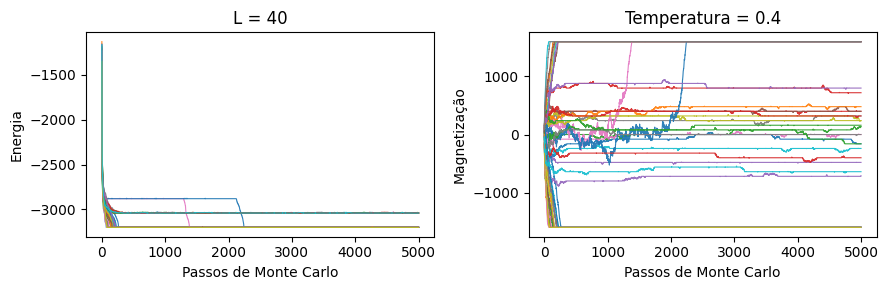

Calor específico médio: 0.003247, Erro: 0.000817
Suscetibilidade magnética média: 0.247724, Erro: 0.090574
Energia média: 3135.777040, Erro: 11.236599
Magnetização média: 1099.133120, Erro: 90.257424


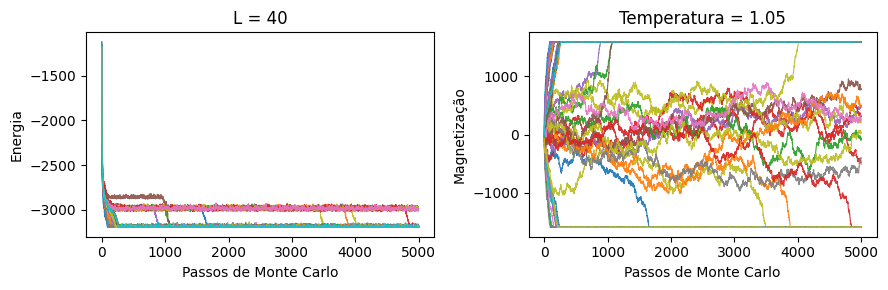

Calor específico médio: 0.108152, Erro: 0.065460
Suscetibilidade magnética média: 3.696744, Erro: 1.457831
Energia média: 3148.789920, Erro: 11.984707
Magnetização média: 1345.543760, Erro: 69.629161


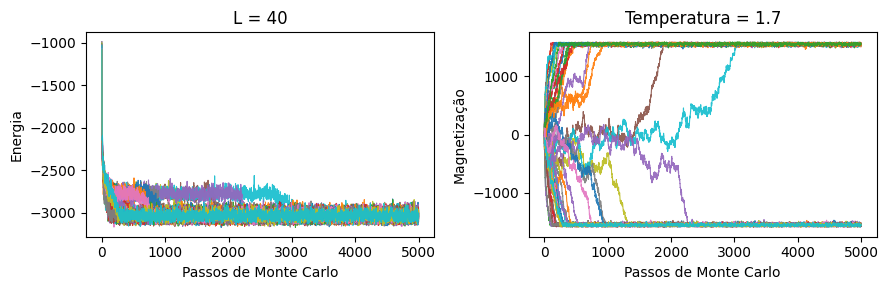

Calor específico médio: 0.344608, Erro: 0.003467
Suscetibilidade magnética média: 0.070547, Erro: 0.001170
Energia média: 3036.572880, Erro: 0.389561
Magnetização média: 1551.905520, Erro: 0.147226


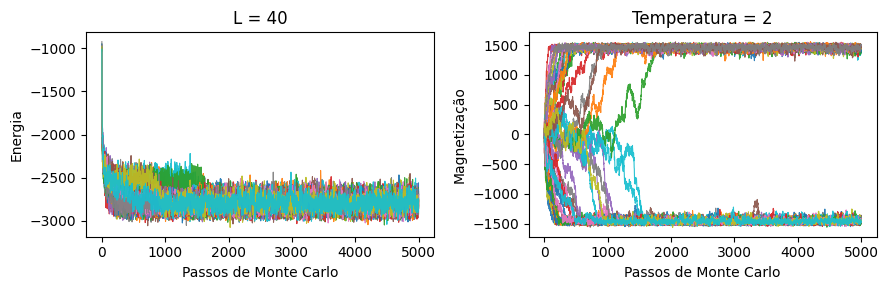

Calor específico médio: 0.718516, Erro: 0.010474
Suscetibilidade magnética média: 0.365837, Erro: 0.011128
Energia média: 2792.792800, Erro: 0.911880
Magnetização média: 1458.416320, Erro: 0.629709


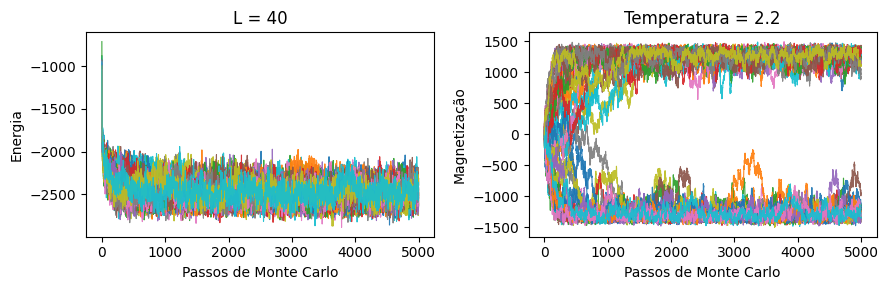

Calor específico médio: 1.306544, Erro: 0.028405
Suscetibilidade magnética média: 3.092891, Erro: 0.337255
Energia média: 2477.923360, Erro: 2.435669
Magnetização média: 1263.502000, Erro: 4.473186


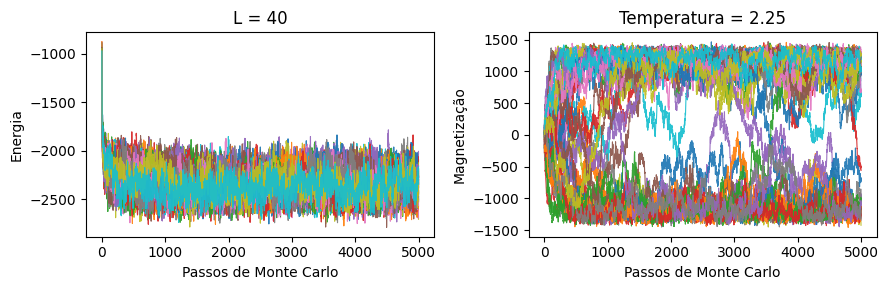

Calor específico médio: 1.563004, Erro: 0.056019
Suscetibilidade magnética média: 9.602763, Erro: 1.281492
Energia média: 2340.001760, Erro: 7.081044
Magnetização média: 1088.310360, Erro: 21.028734


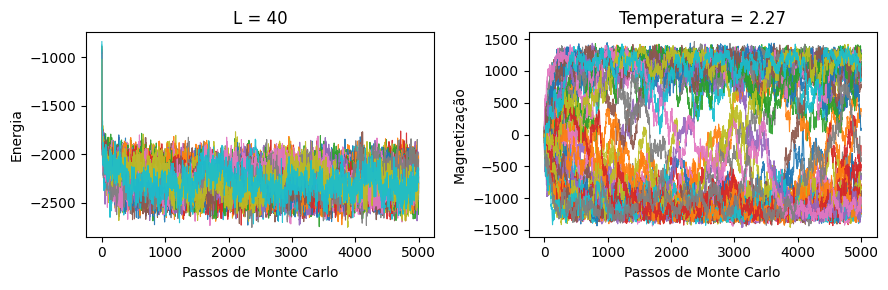

Calor específico médio: 1.736983, Erro: 0.059921
Suscetibilidade magnética média: 14.205870, Erro: 1.762648
Energia média: 2276.816880, Erro: 7.313598
Magnetização média: 989.961240, Erro: 25.919443


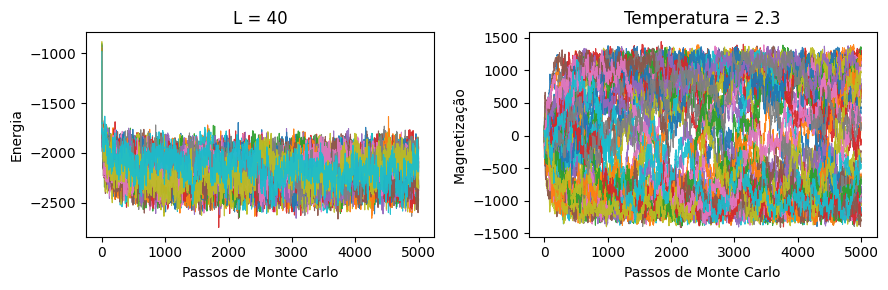

Calor específico médio: 1.565554, Erro: 0.052511
Suscetibilidade magnética média: 16.215578, Erro: 1.504427
Energia média: 2175.503680, Erro: 8.387714
Magnetização média: 818.464040, Erro: 30.794483


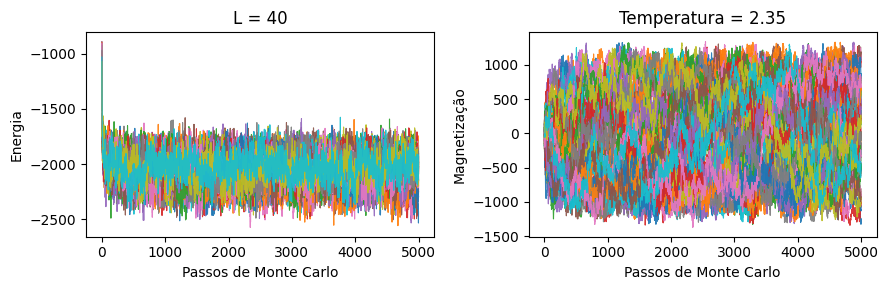

Calor específico médio: 1.449120, Erro: 0.049232
Suscetibilidade magnética média: 19.133688, Erro: 1.070595
Energia média: 2039.761680, Erro: 5.504306
Magnetização média: 566.576280, Erro: 22.604844


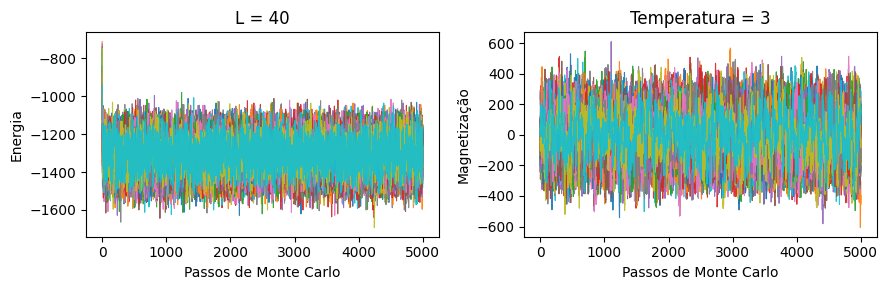

Calor específico médio: 0.404215, Erro: 0.003294
Suscetibilidade magnética média: 1.402418, Erro: 0.031544
Energia média: 1307.362400, Erro: 0.632655
Magnetização média: 110.817480, Erro: 1.002258


In [ ]:
# Simulacoes L = 40

L = 40

T = 0.4
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 0.4", L, beta, n, passos_mc, last_mc)

T = 1.05
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 1.05", L, beta, n, passos_mc, last_mc)

T = 1.7
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 1.7", L, beta, n, passos_mc, last_mc)

T = 2
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 2", L, beta, n, passos_mc, last_mc)

T = 2.2
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 2.2", L, beta, n, passos_mc, last_mc)

T = 2.25
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 2.25", L, beta, n, passos_mc, last_mc)

T = 2.27
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 2.27", L, beta, n, passos_mc, last_mc)

T = 2.3
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 2.3", L, beta, n, passos_mc, last_mc)

T = 2.35
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 2.35", L, beta, n, passos_mc, last_mc)

T = 3
beta = 1 / T
simulacoes2("L = 40", "Temperatura = 3", L, beta, n, passos_mc, last_mc)

À medida que a temperatura se aproxima de 𝑇 ≈ 2.27, observam-se aumentos significativos nas flutuações de energia e magnetização, indicando a proximidade da temperatura crítica para a transição de fase. Nesse ponto, a energia média aumenta devido à desordem térmica, e a magnetização média diminui, refletindo o desalinhamento dos spins. Essas flutuações representam o equilíbrio dinâmico entre as configurações ordenadas e desordenadas. Além disso, o calor específico e a susceptibilidade magnética também apresentam aumentos próximos à transição, sugerindo absorção e liberação de energia intensificadas pelo sistema.

### Variação do tamanho

Temperatura = 1.7 e Tamanho = 24, 43, 62, 81, 100

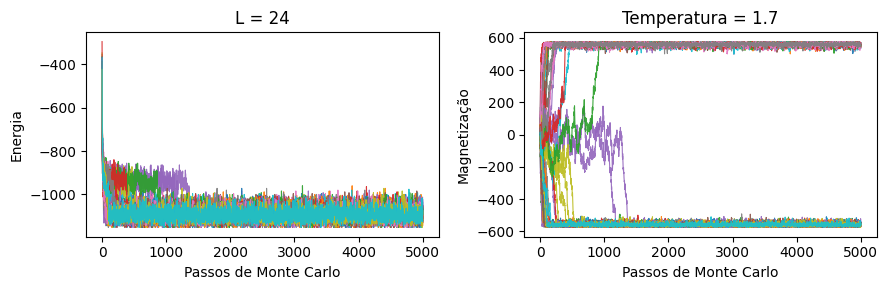

Calor específico médio: 0.342769, Erro: 0.003108
Suscetibilidade magnética média: 0.069630, Erro: 0.001086
Energia média: 1093.008640, Erro: 0.193792
Magnetização média: 558.641680, Erro: 0.074567


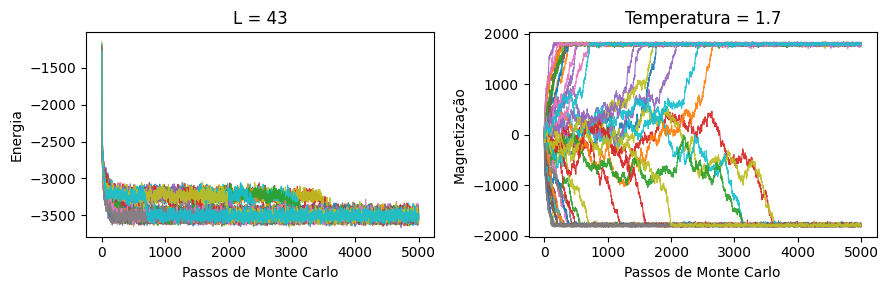

Calor específico médio: 0.342566, Erro: 0.003141
Suscetibilidade magnética média: 0.069405, Erro: 0.000977
Energia média: 3509.770560, Erro: 0.318251
Magnetização média: 1793.678240, Erro: 0.125385


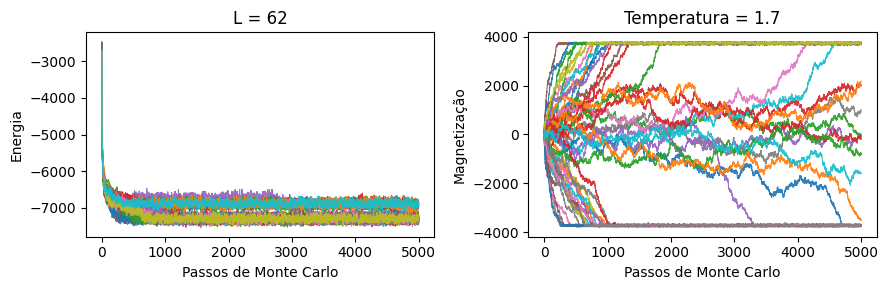

Calor específico médio: 0.475816, Erro: 0.077364
Suscetibilidade magnética média: 7.085590, Erro: 2.895757
Energia média: 7214.744320, Erro: 22.262545
Magnetização média: 3186.607240, Erro: 159.174686


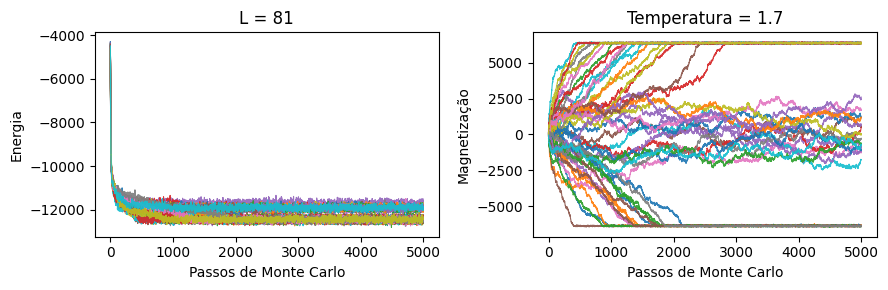

Calor específico médio: 0.351778, Erro: 0.003525
Suscetibilidade magnética média: 2.663866, Erro: 0.695243
Energia média: 12276.364560, Erro: 37.193601
Magnetização média: 4652.094800, Erro: 359.585816


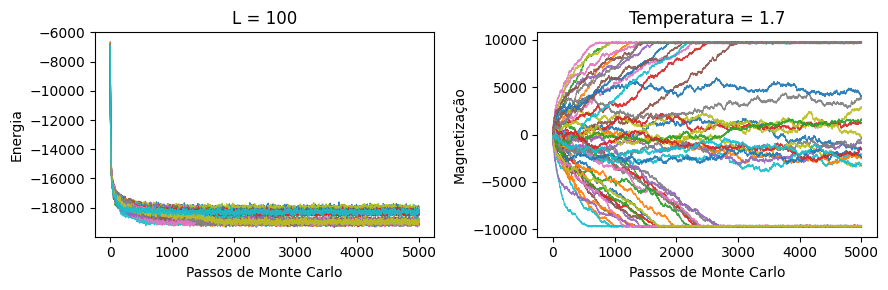

Calor específico médio: 0.345289, Erro: 0.003497
Suscetibilidade magnética média: 3.624058, Erro: 1.145778
Energia média: 18768.808240, Erro: 46.935466
Magnetização média: 7387.836120, Erro: 510.329437


In [ ]:
# Simulacoes T = 1.7

T = 1.7
beta = 1 / T

L = 24
simulacoes2("L = 24", "Temperatura = 1.7", L, beta, n, passos_mc, last_mc)

L = 43
simulacoes2("L = 43", "Temperatura = 1.7", L, beta, n, passos_mc, last_mc)

L = 62
simulacoes2("L = 62", "Temperatura = 1.7", L, beta, n, passos_mc, last_mc)

L = 81
simulacoes2("L = 81", "Temperatura = 1.7", L, beta, n, passos_mc, last_mc)

L = 100
simulacoes2("L = 100", "Temperatura = 1.7", L, beta, n, passos_mc, last_mc)

O efeito do tamanho do sistema é perceptível nas propriedades termodinâmicas. Em sistemas menores, as flutuações são mais intensas, o que pode suavizar características críticas, como os picos no calor específico ou na susceptibilidade magnética, que surgem claramente em sistemas maiores. Redes grandes apresentam flutuações reduzidas e evidenciam melhor a transição de fase, aproximando-se do comportamento que seria observado no limite termodinâmico.

### Comportamento dos erros estatísticos

Os erros estatísticos tendem a aumentar na região próxima da temperatura crítica, onde as flutuações são máximas. Em temperaturas muito baixas (fase ordenada) e muito altas (fase desordenada), os erros são menores, pois o sistema está em configurações mais estáveis e menos sensíveis a variações aleatórias. Próximo da transição de fase, a competição entre estados ordenados e desordenados dificulta a convergência dos dados e eleva os erros estatísticos.

### Fases do sistema

**Fase Ordenada:** Em baixas temperaturas, o sistema está na fase ferromagnética, com magnetização média significativa por spin e os spins alinhados, formando uma configuração ordenada e de baixa energia. Nessa fase, a susceptibilidade magnética é baixa, pois a magnetização não responde fortemente a pequenas variações no campo externo.

**Fase Desordenada:** Em altas temperaturas, o sistema entra na fase paramagnética, onde a magnetização média é próxima de zero devido ao desalinhamento dos spins pela energia térmica elevada. A energia por spin aumenta, e a susceptibilidade magnética é geralmente baixa, exceto ao redor da temperatura crítica, onde um pico ocorre em resposta às grandes flutuações.



### Temperatura de transição

 A temperatura de transição parece estar em torno de T = 2.27.